In [1]:
library(ggplot2)
library(ggridges)
library(cowplot)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:
fns = list.files("../data/")
conds = sapply(fns, function(x) strsplit(x, '_')[[1]][1])
rep = sapply(fns, function(x) as.numeric(gsub('.txt', '', strsplit(fns[1], '_rep')[[1]][2])))
samples = cbind(fns, conds, rep)
head(samples)

,fns,conds,rep
brq100_rep1.txt,brq100_rep1.txt,brq100,1
brq100_rep2.txt,brq100_rep2.txt,brq100,1
brq100_rep3.txt,brq100_rep3.txt,brq100,1
brq2_rep1.txt,brq2_rep1.txt,brq2,1
brq2_rep2.txt,brq2_rep2.txt,brq2,1
brq2_rep3.txt,brq2_rep3.txt,brq2,1


In [6]:
paste("../data/", samples[1,1], sep='')

[1] "../data/brq100_rep1.txt"

In [7]:
data = read.table(paste("../data/", "brq100_rep1.txt", sep=''), header=T)
data$cond = strsplit(fn, '_')[[1]][1]
data$rep = as.numeric(gsub('.txt', '', strsplit(fn, '_rep')[[1]][2]))
head(data)

ERROR: Error in strsplit(fn, "_"): object 'fn' not found


In [8]:
df = data.frame(matrix(ncol=7))
names(df) = c("filename", "num_maxima", "area", "dapi", "yh2ax", "cond", "rep")
for (i in 1:length(fns)) {
    fn = samples[i,1]
    data = read.table(paste("../data/", fn, sep=''), header=T)
    data$cond = strsplit(fn, '_')[[1]][1]
    data$rep = as.numeric(gsub('.txt', '', strsplit(fn, '_rep')[[1]][2]))
    df = rbind(df, data)
}
df = df[2:dim(df)[1],]
df$rep = factor(df$rep, levels=c(1,2,3))
head(df)

,filename,num_maxima,area,dapi,yh2ax,cond,rep
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
2,211210_BD294_yh2ax_CIS100_NCS100_BRQ100_REPS1-2-3_041_R3D_D3D.dv,2,80.961,449.499,330.126,brq100,1
3,211210_BD294_yh2ax_CIS100_NCS100_BRQ100_REPS1-2-3_041_R3D_D3D.dv,20,139.173,577.878,478.727,brq100,1
4,211210_BD294_yh2ax_CIS100_NCS100_BRQ100_REPS1-2-3_041_R3D_D3D.dv,1,87.271,532.406,280.748,brq100,1
5,211210_BD294_yh2ax_CIS100_NCS100_BRQ100_REPS1-2-3_041_R3D_D3D.dv,14,161.647,591.193,858.977,brq100,1
6,211210_BD294_yh2ax_CIS100_NCS100_BRQ100_REPS1-2-3_041_R3D_D3D.dv,12,129.455,545.236,857.264,brq100,1
7,211210_BD294_yh2ax_CIS100_NCS100_BRQ100_REPS1-2-3_041_R3D_D3D.dv,13,129.824,698.217,649.192,brq100,1


In [114]:
df$dapi_area = df$dapi * df$area

Picking joint bandwidth of 6860



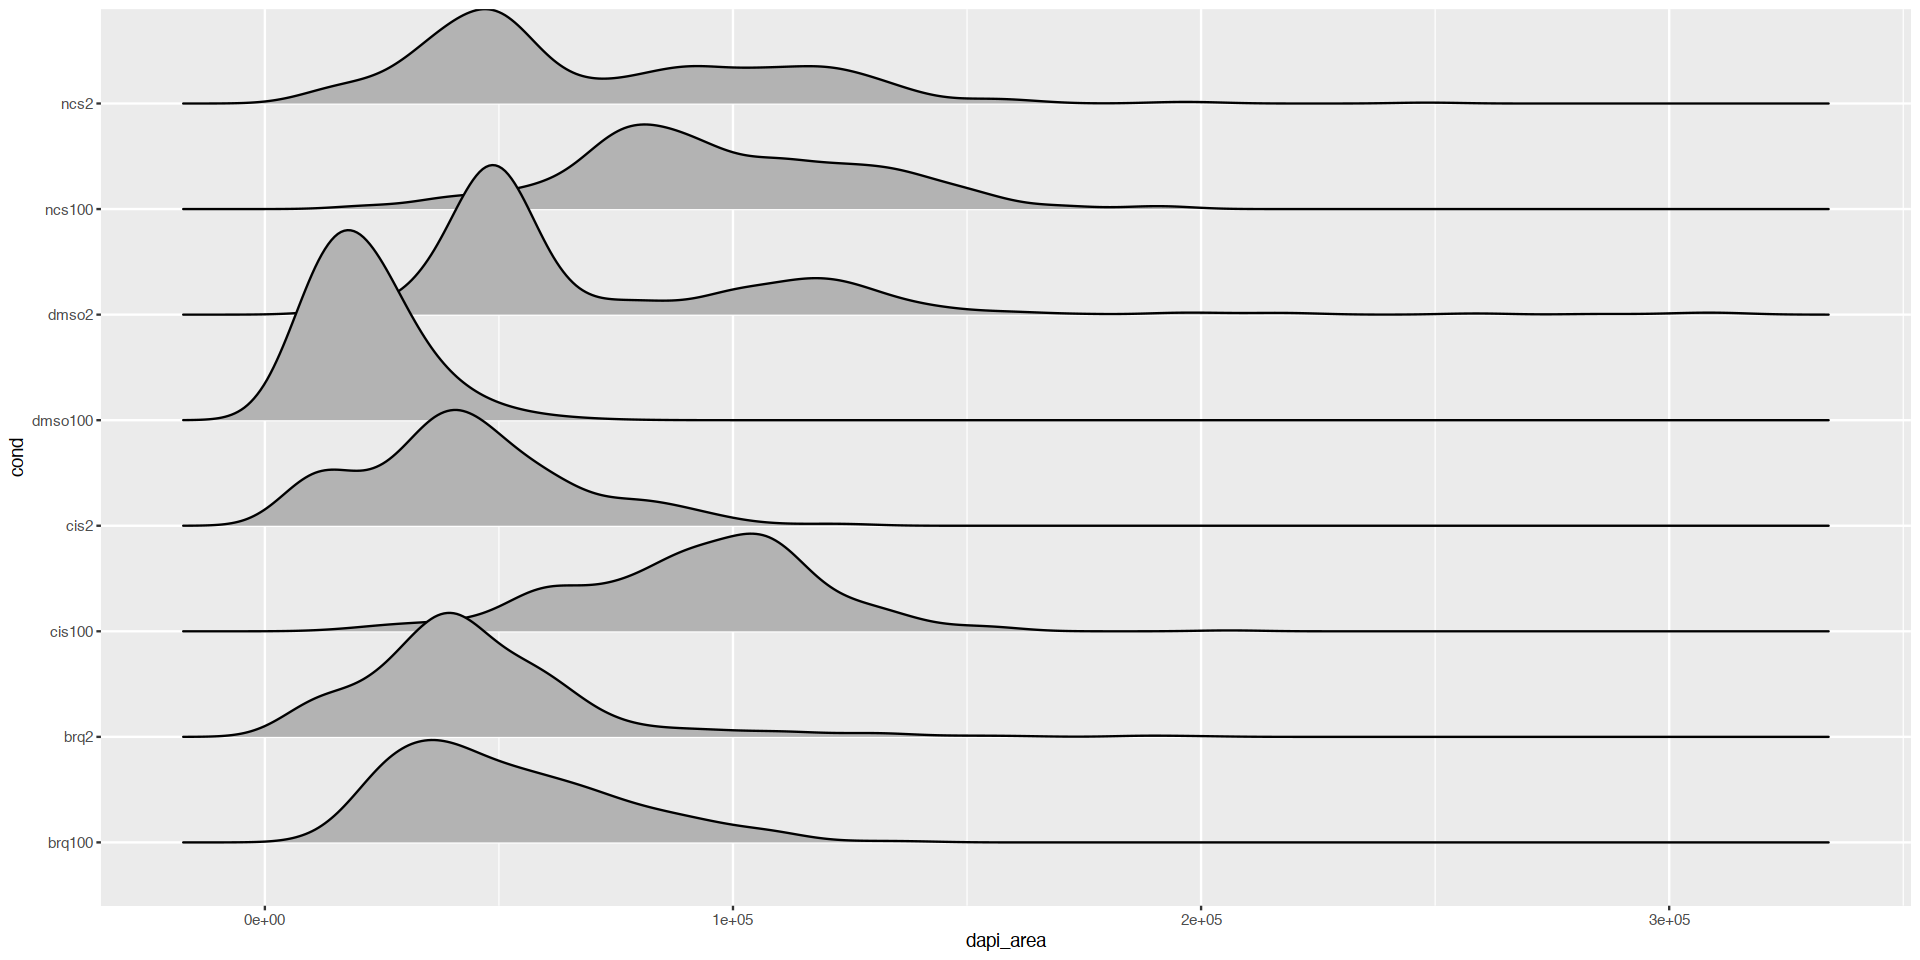

In [115]:
ggplot(data=df, aes(x=dapi_area, y=cond)) + geom_density_ridges()


Picking joint bandwidth of 1.1



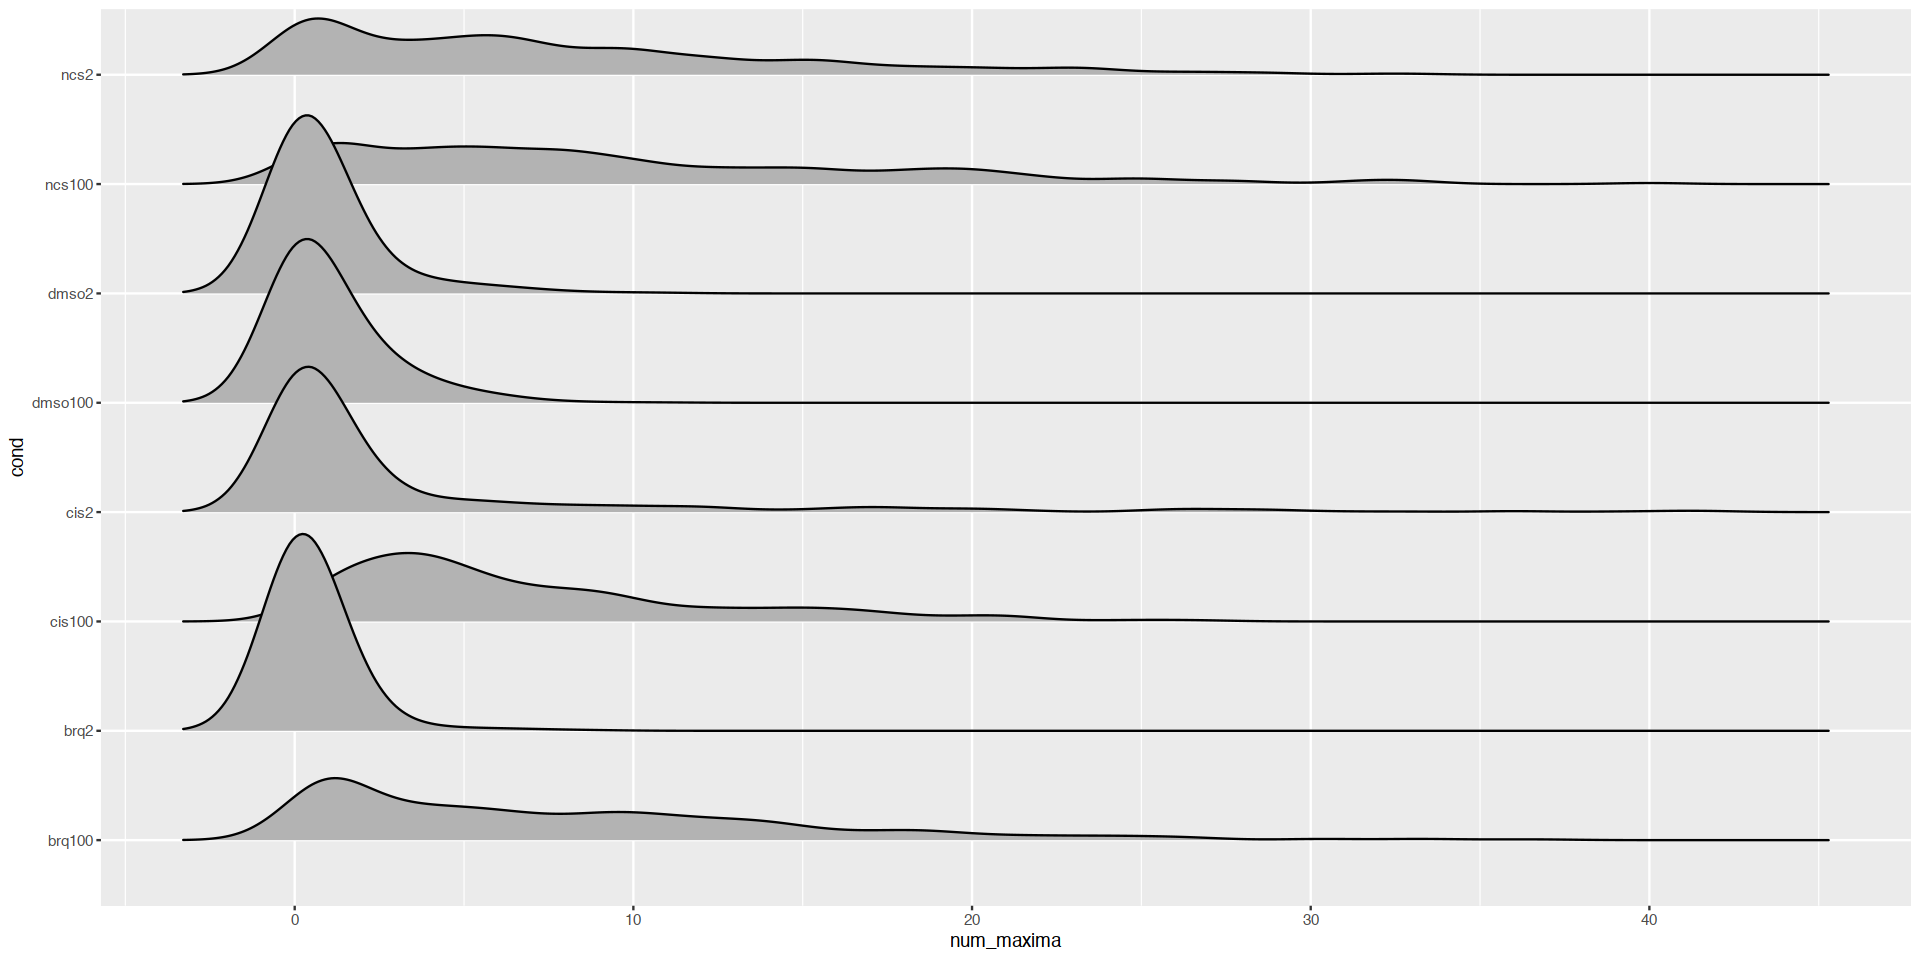

In [116]:
ggplot(data=df, aes(x=num_maxima, y=cond)) + geom_density_ridges()


Picking joint bandwidth of 31.3

Warning message:
“Removed 35 rows containing non-finite values (stat_density_ridges).”


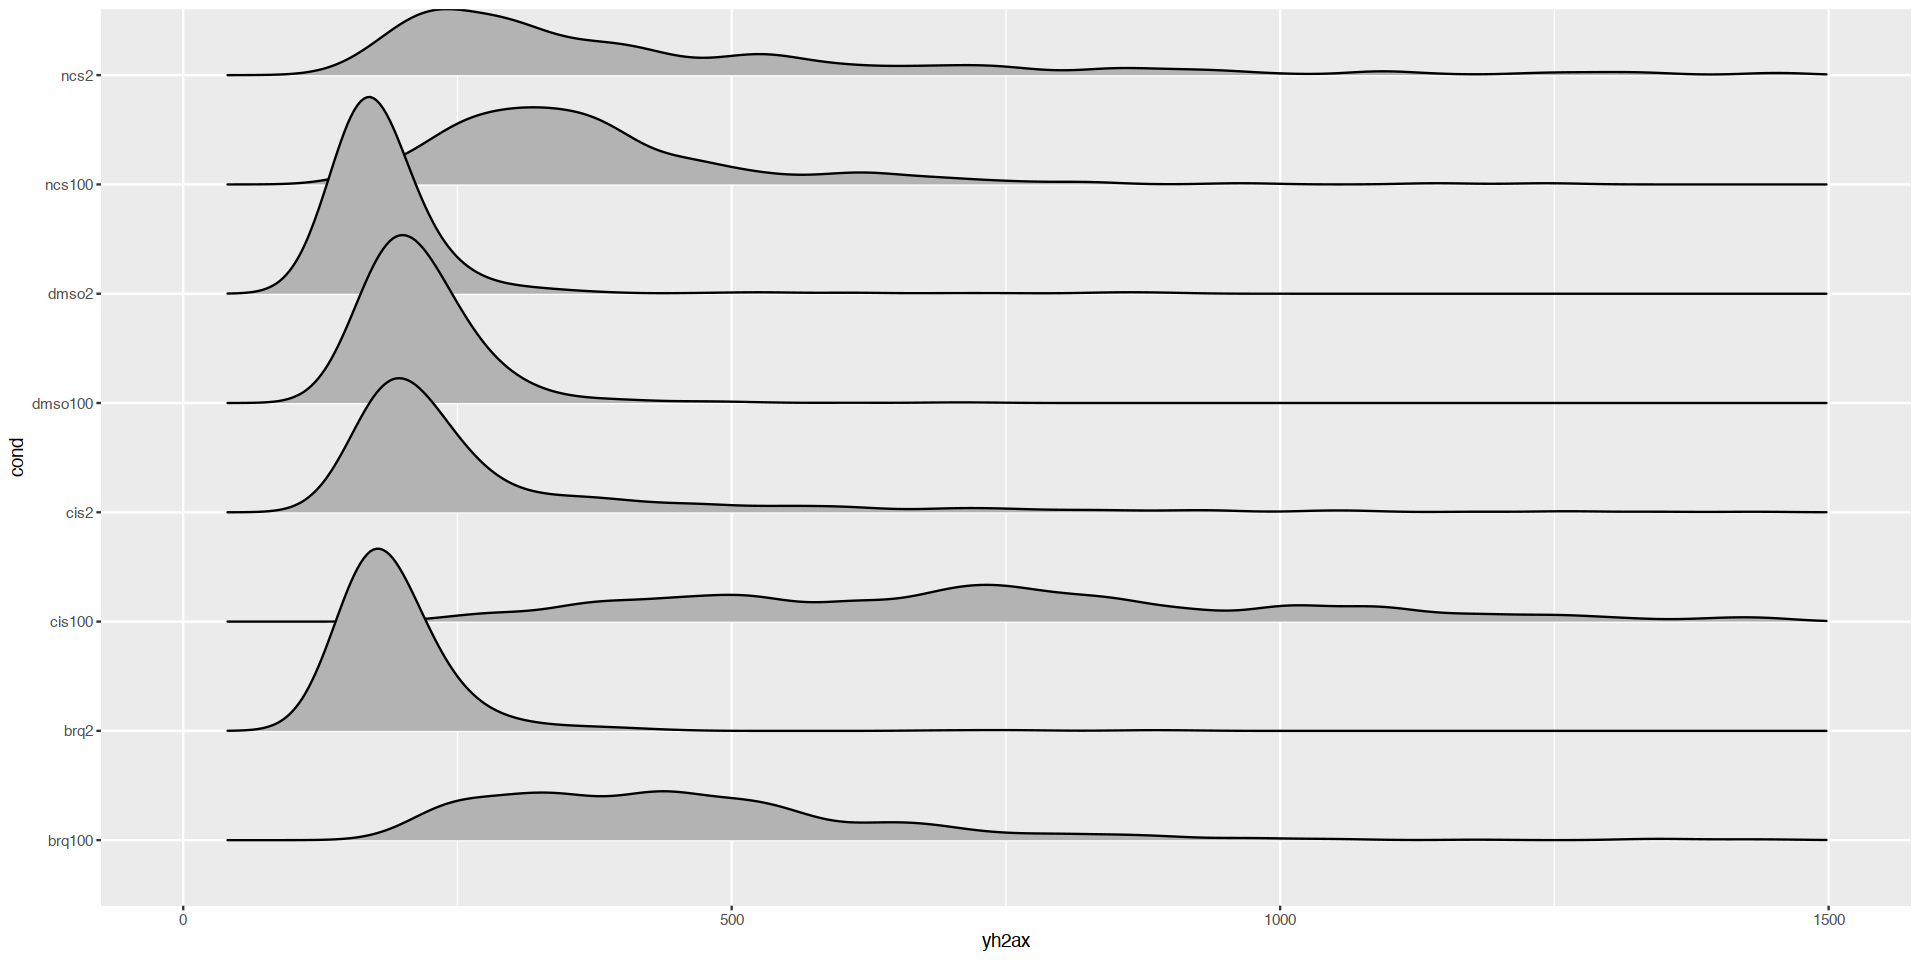

In [117]:
ggplot(data=df, aes(x=yh2ax, y=cond)) + geom_density_ridges() + xlim(0,1500)

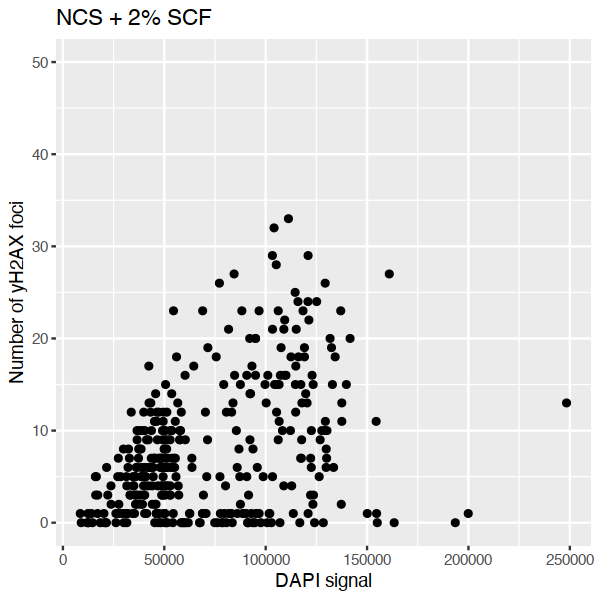

In [96]:
options(repr.plot.width = 5, repr.plot.height = 5)
ggplot(data=df[df$cond == "ncs2",], aes(x=dapi_area, y=num_maxima)) + geom_point() + 
ylim(c(0,50)) + ylab("Number of yH2AX foci") + xlab("DAPI signal") + ggtitle("NCS + 2% SCF")

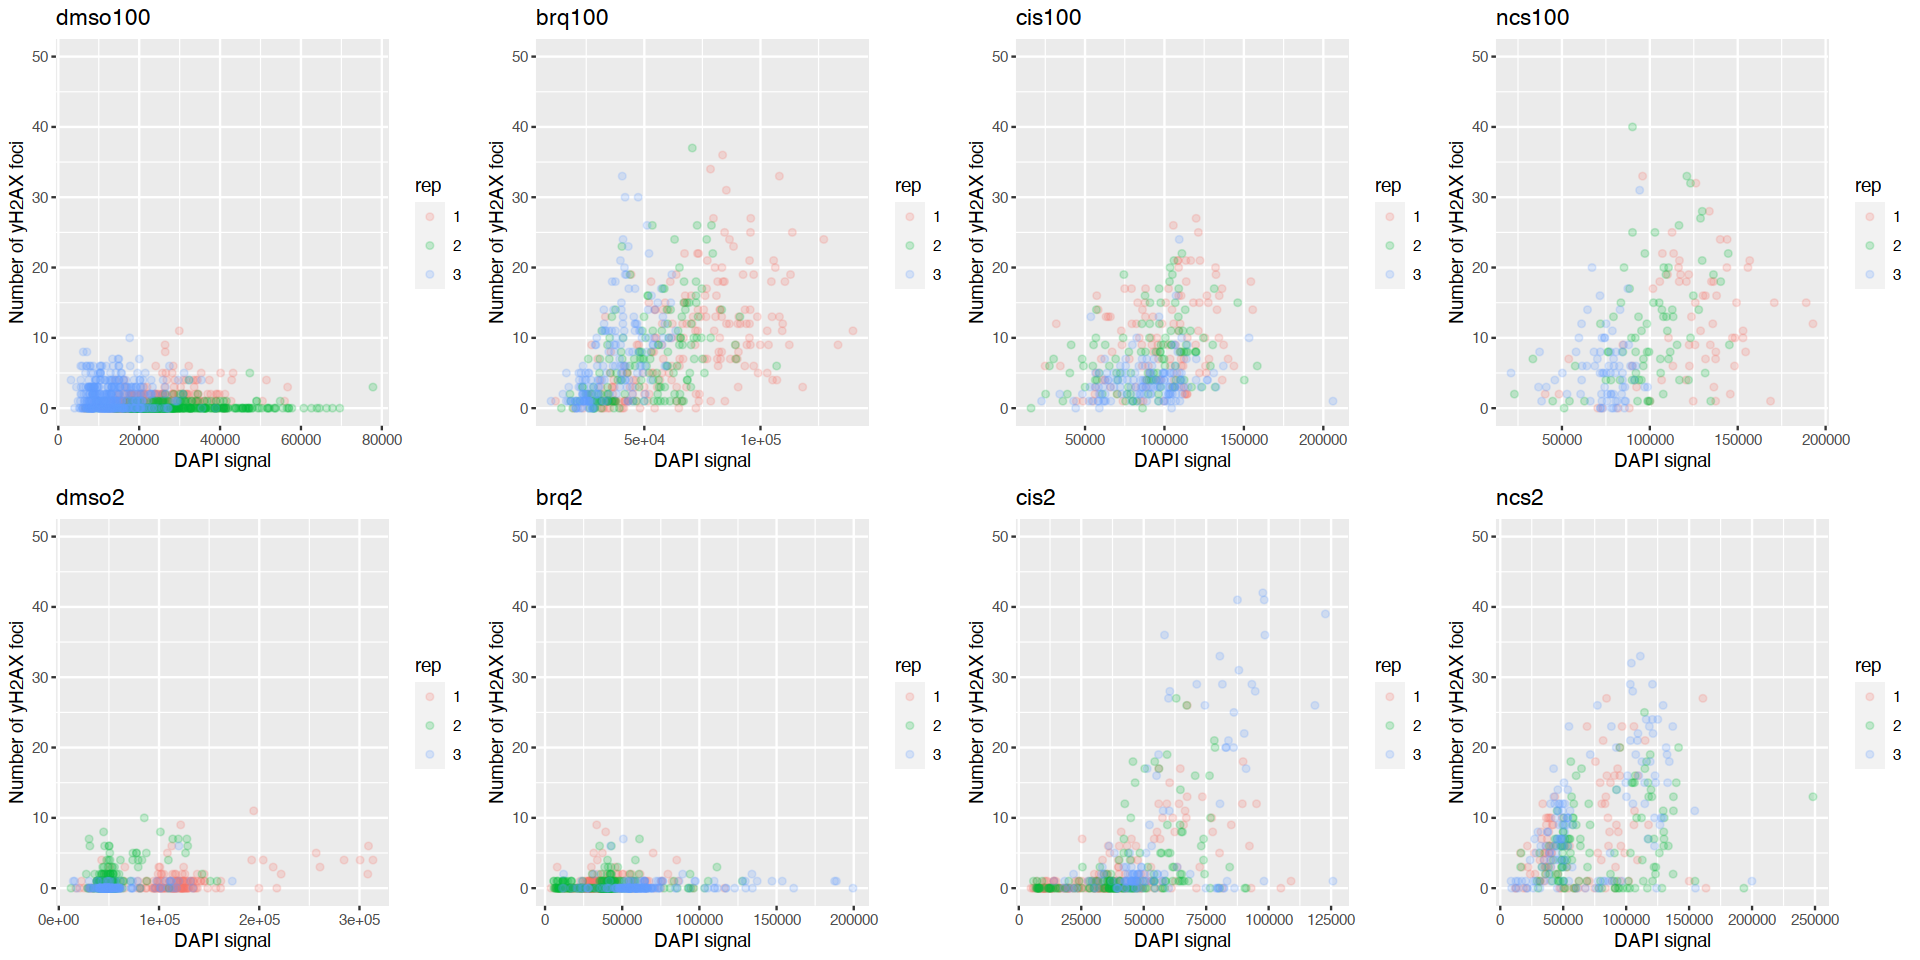

In [120]:
options(repr.plot.width = 16, repr.plot.height = 8)
pf = function(z) {
    p1 = ggplot(data=df[df$cond == z,], aes(x=dapi_area, y=num_maxima)) + geom_point(aes(color=rep), alpha=0.2) + 
    ylim(c(0,50)) + ylab("Number of yH2AX foci") + xlab("DAPI signal") + ggtitle(z)
    return(p1)
}

plot_grid(pf("dmso100"), pf("brq100"), pf("cis100"), pf("ncs100"), 
          pf("dmso2"), pf("brq2"), pf("cis2"), pf("ncs2"),
          nrow=2)

In [10]:
df_summ = df %>% group_by(cond, rep) %>% summarize(
  num_cells = length(yh2ax),
  yh2ax = median(yh2ax),
  foci = median(num_maxima),
  foci_pct = sum(num_maxima > 5)/sum(num_maxima > -1) * 100,
) 
df_summ$tx = c(rep("BRQ", 6), rep("CIS", 6), rep("DMSO", 6), rep("NCS", 6))
df_summ$scf = rep(c(100, 100, 100, 2, 2, 2), 4)
df_summ$tx = factor(df_summ$tx, levels=c("DMSO", "BRQ", "CIS", "NCS"))
df_summ$scf = factor(df_summ$scf, levels=c(100, 2))
head(df_summ)

write.csv(df_summ, "220104_bd294_medians.csv", quote=F)

`summarise()` has grouped output by 'cond'. You can override using the `.groups` argument.



cond,rep,num_cells,yh2ax,foci,foci_pct,tx,scf
<chr>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
brq100,1,201,470.0030,8,60.6965174,BRQ,100
brq100,2,164,418.3625,5,49.3902439,BRQ,100
brq100,3,183,411.1300,5,46.4480874,BRQ,100
brq2,1,209,192.6110,0,0.9569378,BRQ,2
brq2,2,235,179.3970,0,1.2765957,BRQ,2
brq2,3,189,168.6110,0,1.0582011,BRQ,2


pdf 
  2

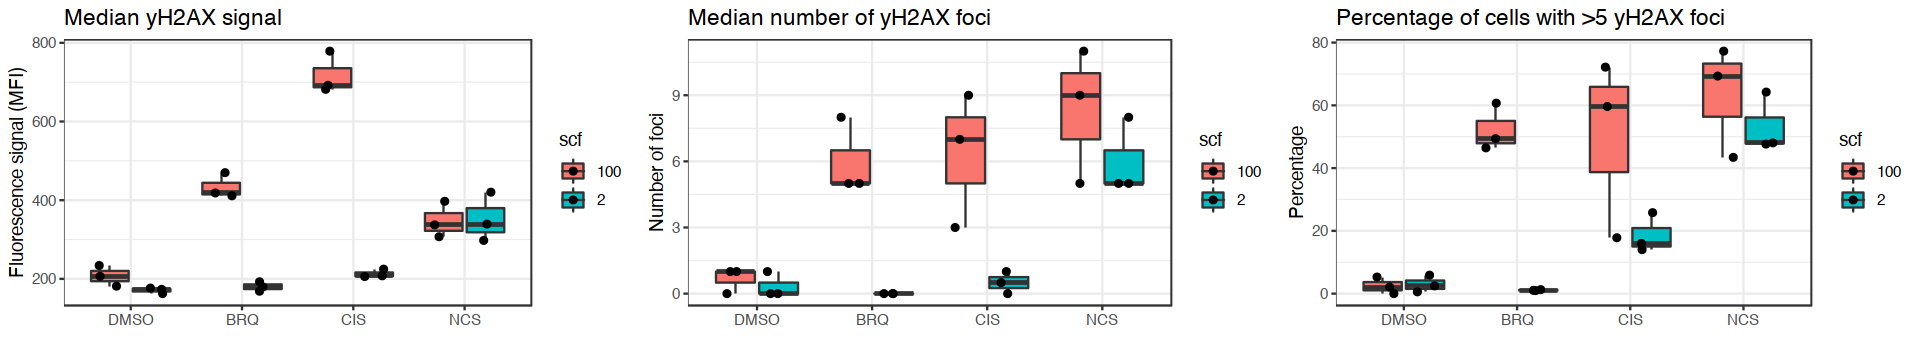

In [168]:
options(repr.plot.width=16, repr.plot.height=3)

p1 = ggplot(df_summ, aes(x=tx, y=yh2ax, fill=scf)) + geom_boxplot() + 
geom_point(position = position_jitterdodge()) + theme_bw() + 
ggtitle("Median yH2AX signal") + ylab("Fluorescence signal (MFI)") + xlab("")

p2 = ggplot(df_summ, aes(x=tx, y=foci, fill=scf)) + 
geom_boxplot() + geom_point(position = position_jitterdodge()) + theme_bw() + 
ggtitle("Median number of yH2AX foci") + ylab("Number of foci") + xlab("")

p3 = ggplot(df_summ, aes(x=tx, y=foci_pct, fill=scf)) + 
geom_boxplot() + geom_point(position = position_jitterdodge()) + theme_bw() + 
ggtitle("Percentage of cells with >5 yH2AX foci") + ylab("Percentage") + xlab("")

plot_grid(p1, p2, p3, nrow=1)

pdf("220104_bd294_medians.pdf", width=15, height=3)
plot_grid(p1, p2, p3, nrow=1)
dev.off()

Warning message:
“Removed 35 rows containing non-finite values (stat_ydensity).”


ERROR: Error in ggtitle("Median yH2AX signal") + ylab("Fluorescence signal (MFI)"): non-numeric argument to binary operator


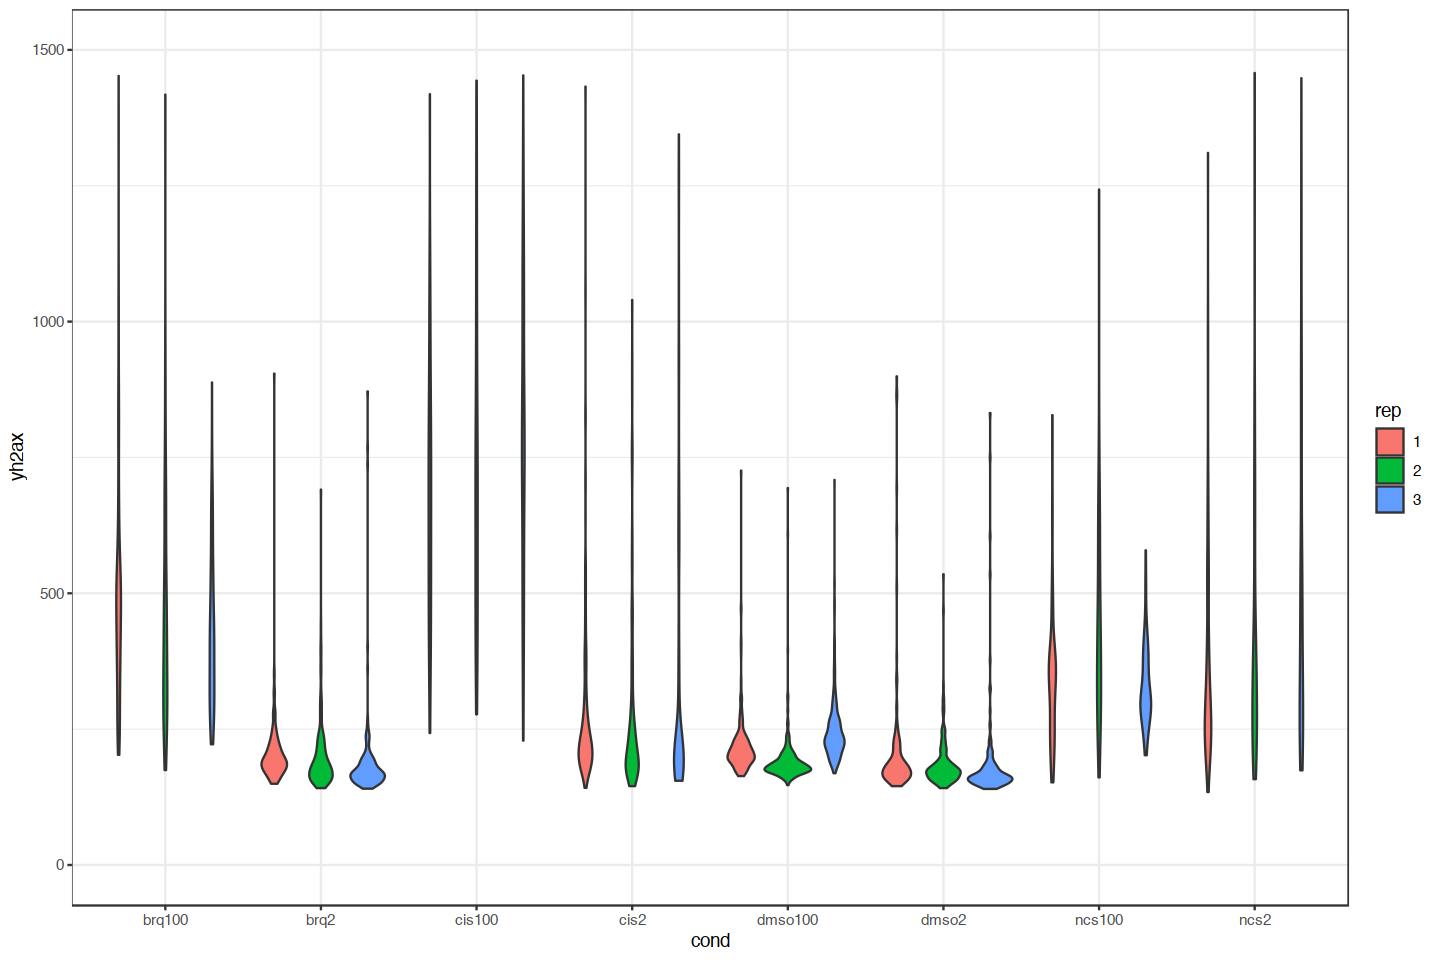

In [161]:
options(repr.plot.width=12, repr.plot.height=8)

ggplot(df, aes(x=cond, y=yh2ax, fill=rep)) + geom_violin() + 
theme_bw() + ylim(c(0,1500))
ggtitle("Median yH2AX signal") + ylab("Fluorescence signal (MFI)") + xlab("")

Warning message:
“Removed 116 rows containing non-finite values (stat_boxplot).”


ERROR: Error in ggtitle("Median yH2AX signal") + ylab("Fluorescence signal (MFI)"): non-numeric argument to binary operator


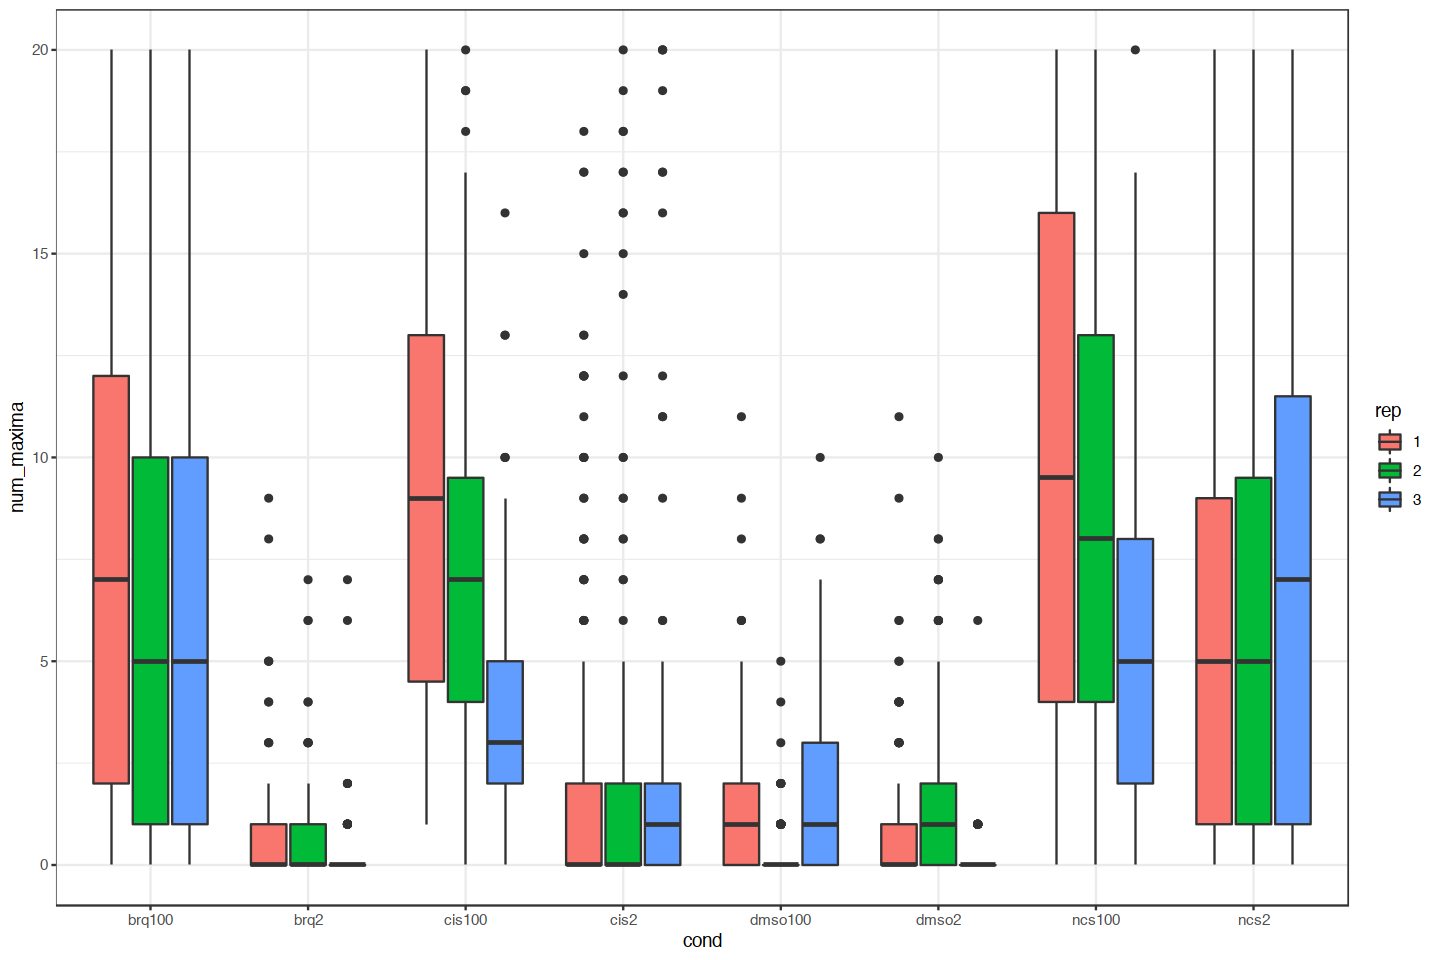

In [163]:
options(repr.plot.width=12, repr.plot.height=8)

ggplot(df, aes(x=cond, y=num_maxima, fill=rep)) + geom_boxplot() + 
theme_bw() + ylim(c(0,20))
ggtitle("Median yH2AX signal") + ylab("Fluorescence signal (MFI)") + xlab("")

Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”


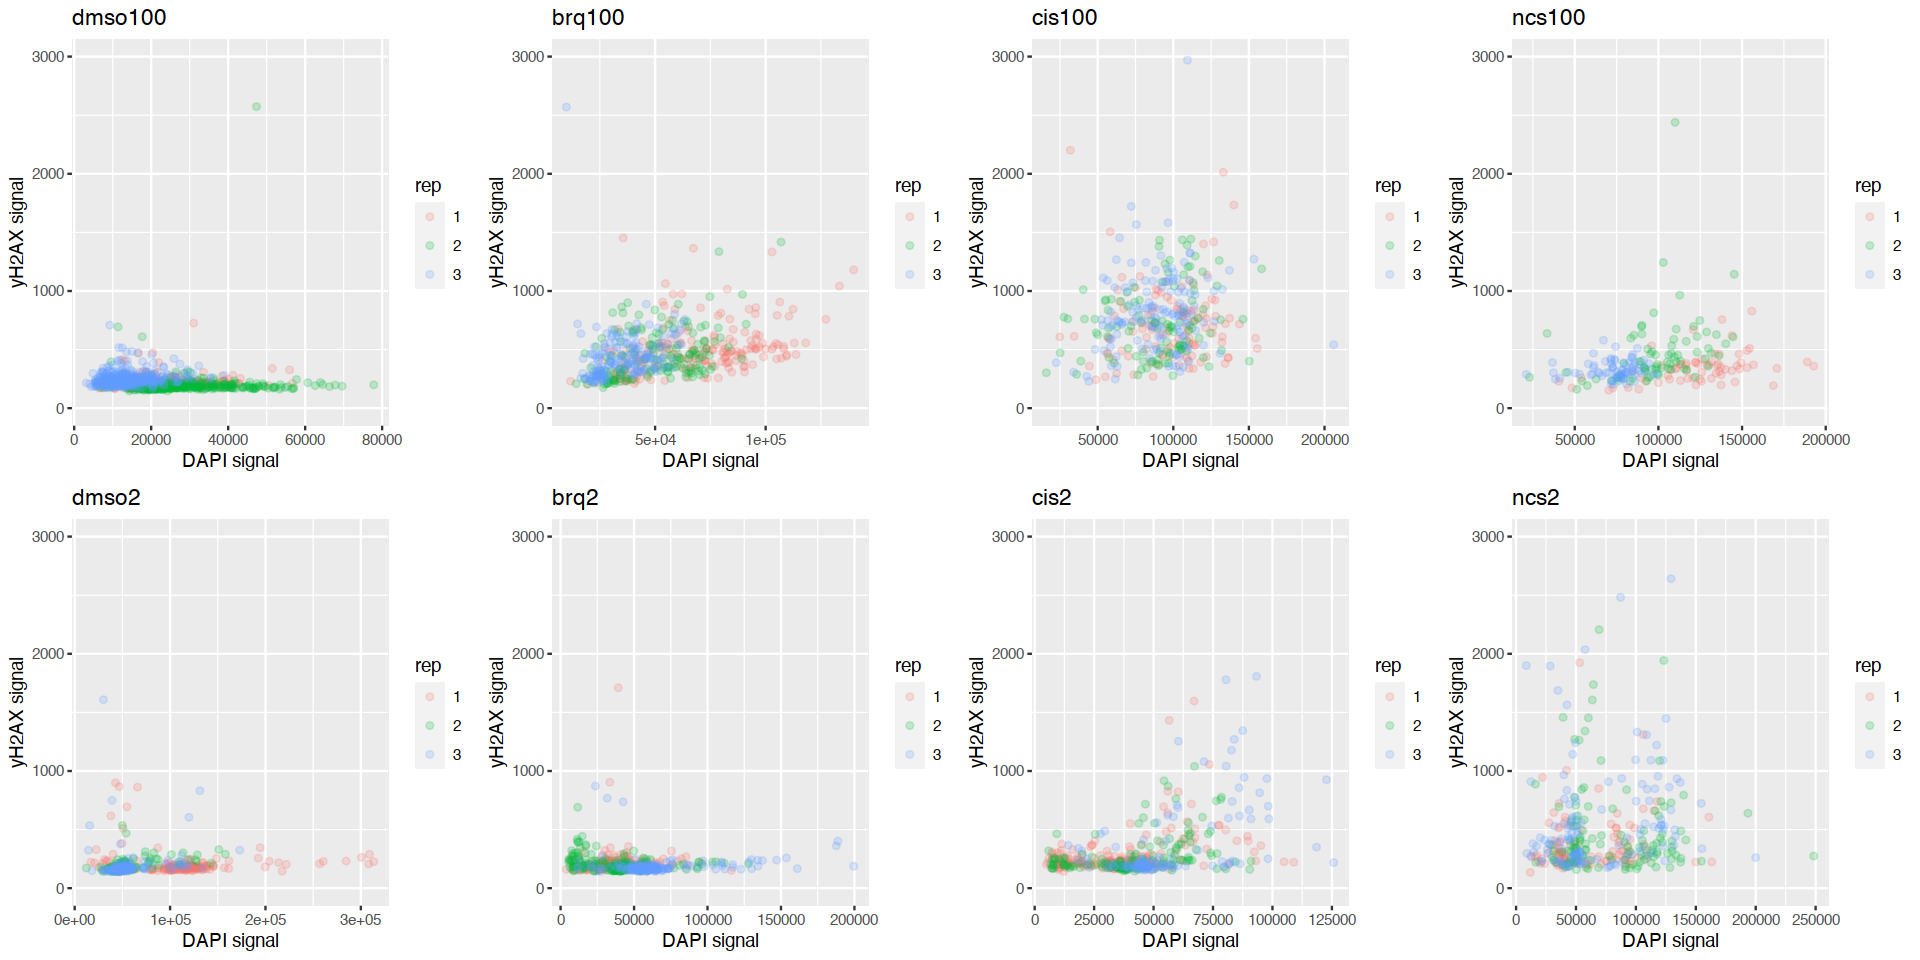

In [119]:
options(repr.plot.width = 16, repr.plot.height = 8)
pn = function(z) {
    p1 = ggplot(data=df[df$cond == z,], aes(x=dapi_area, y=yh2ax)) + geom_point(aes(color=rep), alpha=0.2) + 
    ylim(0,3000) + ylab("yH2AX signal") + xlab("DAPI signal") + ggtitle(z)
    return(p1)
}

plot_grid(pn("dmso100"), pn("brq100"), pn("cis100"), pn("ncs100"), 
          pn("dmso2"), pn("brq2"), pn("cis2"), pn("ncs2"),
          nrow=2)